## tl;dr

**Decision: proceed with a bounded broad Atlas, not a Q-Neko-only deep dive.**

- Observed EU27-Japan quantum publications (2020-2026): **645**.
- Explicit project and funder relations: **60.8%** each (392/645).
- Dataset relations: **27.8%** (179/645; full-corpus audit, Wilson 95% interval 24.4%-31.3%).
- Software relations: **7.4%** (48/645; Wilson 95% CI 5.7%-9.7%).
- At the 29 July snapshot, Q-Neko aliases and call identifier returned **0 projects and 0 research products**. By the separate 13 August bounded recheck, one exact project was visible; four raw product hits became three after the Atlas itself was excluded, and those three records also resolved through the explicit Q-NEKO project-code relation.

The broad graph is usable for a provenance-first evidence atlas, but software reuse must be presented as a metadata observability gap rather than an activity gap.

## Context & Methods

### Key Assumptions

- Scope is conservative: a record must match at least one of eight exact quantum phrases and resolve to at least one Japanese and one EU27 affiliation.
- The analysis window is publication years 2020-2026. The current source retrieval window ends at 2026-07-29T00:13:14Z.
- A project connection requires an explicit OpenAIRE result-project relation. A funding connection requires a funder object inside that relation; the unreliable top-level `publiclyFunded` flag is not used.
- Dataset/software connections use both directions of the OpenAIRE Scholix link endpoint.
- Dataset/software rates audit all 645 observed records. A stricter title-literal subset of 87 records remains as a sensitivity check.

Sources: OpenAIRE Graph V3 research products/projects/organizations and Graph V1 Scholix links. Current-run responses use a date-stamped cache; historical replay requires an explicit cache directory.

## Data

Install the declared Python environment with `python -m pip install -r requirements-analysis.txt`. The notebook resolves the published CSV/JSON snapshot from either the repository root, the `public/reproducibility` directory, or a standalone reproducibility directory; it does not depend on an unshipped `analysis/output` folder.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_CANDIDATES = [
    Path.cwd() / 'public' / 'reproducibility',
    Path.cwd() / 'reproducibility',
    Path.cwd(),
]
DATA = next((path for path in DATA_CANDIDATES if (path / 'metrics.json').exists()), None)
if DATA is None:
    raise FileNotFoundError('Published metrics.json not found; run from the repository/release root or reproducibility directory.')
metrics = json.loads((DATA / 'metrics.json').read_text(encoding='utf-8'))
corpus = pd.read_csv(DATA / 'eu27_japan_corpus.csv')
links = pd.read_csv(DATA / 'scholix_link_audit.csv')
len(corpus), len(links)

(645, 645)

In [2]:
assert len(corpus) == metrics['eu27_japan_observed_publications']
assert corpus['id'].is_unique and links['id'].is_unique
assert set(corpus['id']) == set(links['id'])
assert metrics['quality_checks']['scholix_missing_records'] == 0
pd.DataFrame([
    {'check': 'full corpus rows', 'value': len(corpus)},
    {'check': 'full Scholix audit rows', 'value': len(links)},
    {'check': 'missing link-audit rows', 'value': len(set(corpus['id']) - set(links['id']))},
    {'check': 'duplicate corpus ids', 'value': int(corpus['id'].duplicated().sum())},
    {'check': 'duplicate link-audit ids', 'value': int(links['id'].duplicated().sum())},
])

,check,value
0,full corpus rows,645
1,full Scholix audit rows,645
2,missing link-audit rows,0
3,duplicate corpus ids,0
4,duplicate link-audit ids,0


In [3]:
summary = pd.DataFrame([
    {'metric': name, 'numerator': item['numerator'], 'denominator': item['denominator'], 'rate': item['rate']}
    for name, item in metrics['rates'].items()
])
summary.assign(rate=summary['rate'].map(lambda value: f'{value:.1%}'))

,metric,numerator,denominator,rate
0,project,392,645,60.8%
1,funding,392,645,60.8%
2,dataset,179,645,27.8%
3,software,48,645,7.4%


## Results

In [4]:
strict_summary = pd.DataFrame([
    {'metric': name, 'numerator': item['numerator'], 'denominator': item['denominator'], 'rate': item['rate']}
    for name, item in metrics['strict_title_sensitivity'].items() if isinstance(item, dict)
])
strict_summary.assign(rate=strict_summary['rate'].map(lambda value: f'{value:.1%}'))

,metric,numerator,denominator,rate
0,project,45,87,51.7%
1,funding,45,87,51.7%
2,dataset,21,87,24.1%
3,software,7,87,8.0%


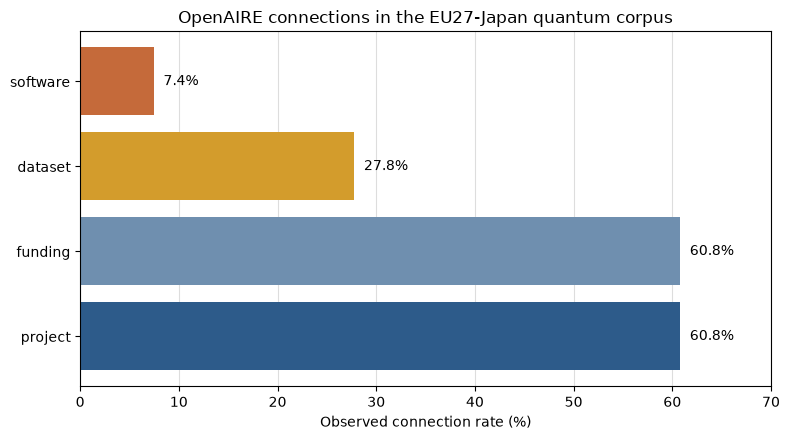

In [5]:
plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#2D5B8A', '#6F8FAF', '#D39C2C', '#C56A3A']
bars = ax.barh(plot_df['metric'], plot_df['rate'] * 100, color=colors)
ax.set_xlim(0, 70)
ax.set_xlabel('Observed connection rate (%)')
ax.set_title('OpenAIRE connections in the EU27-Japan quantum corpus')
ax.grid(axis='x', color='#DDDDDD', linewidth=0.8)
ax.set_axisbelow(True)
for bar, value in zip(bars, plot_df['rate'] * 100):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center')
plt.tight_layout()
plt.show()

In [6]:
quality = metrics['quality_checks']
pd.DataFrame([
    {'check': 'project link but publiclyFunded=false', 'count': quality['project_link_but_publiclyFunded_false']},
    {'check': 'publiclyFunded=true', 'count': quality['publiclyFunded_true']},
    {'check': 'Japan-query records with no resolved country', 'count': quality['records_with_no_resolved_country']},
    {'check': 'Q-Neko project records', 'count': metrics['q_neko']['projects_union']},
    {'check': 'Q-Neko research products', 'count': metrics['q_neko']['research_products_union']},
])

,check,count
0,project link but publiclyFunded=false,386
1,publiclyFunded=true,7
2,Japan-query records with no resolved country,17
3,Q-Neko project records,0
4,Q-Neko research products,0


## Takeaways

1. **The broad Atlas passes the connectivity feasibility gate.** 392 of 645 observed cross-region publications have explicit project/funder edges.
2. **Reusable-output visibility is uneven across the full corpus.** Dataset links are observable for 27.8%, while software links are only 7.4%. The strict-title sensitivity is similar (24.1% dataset; 8.0% software), so the result is not explained by broad abstract matching alone.
3. **Q-Neko is not yet an OpenAIRE-deep-dive candidate.** It is externally documented and newly launched, but no corresponding OpenAIRE project or product record was found under four identifiers/aliases.
4. **Quality check.** All 645 corpus ids are unique, all have a completed Scholix audit, and a prespecified deterministic subset remains available as a secondary reproducibility check.
5. **Product implication.** Build a bounded, curated broad Atlas with an inspectable `not observable in OpenAIRE` state; use Q-Neko as a forward-looking policy anchor and ingestion watchlist, not as the sole evidence corpus.